# Build a Text2SQL ReAct Agentic AI System with LangChain

### Building a Text2SQL ReAct Agentic AI System

In this project, we will design a **Text2SQL ReAct Agentic AI System** to enhance the interaction with databases using natural language queries. This workflow will leverage the `create_react_agent` function from **LangGraph**, which offers a more robust implementation compared to the deprecated LangChain version. The workflow consists of the following components:

1. **Agent System Prompt**: The agent is designed to interpret user questions and generate syntactically correct SQL queries. Key rules include:
   - Limiting results to at most 10 unless specified by the user.
   - Querying only relevant columns instead of retrieving all columns from a table.
   - Ensuring plain text SQL query generation without additional formatting or code blocks.

2. **SQL Database Tools**: The system uses tools to interact with the database schema and validate queries:
   - **DB_QUERY**: Executes the generated SQL query.
   - **DB_SCHEMA**: Fetches the schema details of the database.
   - **DB_LIST_TABLES**: Lists all tables in the database.
   - **DB_QUERY_CHECKER**: Validates the correctness of the SQL query before execution.

3. **SQL Database Engine**: Executes the validated SQL queries and retrieves the required data from the database.

4. **ReAct Reasoning Framework**: The agent combines reasoning with actions to ensure accurate query formulation and execution.

5. **Final Response**: The results are processed and returned to the user in a human-friendly format.

By using LangGraph's `create_react_agent`, this system ensures a more reliable, efficient, and user-friendly interaction with SQL databases, making it easier to extract meaningful insights from structured data.

![](https://i.imgur.com/4PNKql9.png)

## Install OpenAI, and LangChain dependencies

In [ ]:
!pip install langchain==0.3.14
!pip install langchain-openai==0.3.0
!pip install langchain-community==0.3.14
!pip install langgraph==0.2.66
!pip install langchain-experimental==0.3.4

In [ ]:
!apt-get install sqlite3 -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
sqlite3 is already the newest version (3.37.2-2ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


## Enter Open AI API Key

In [ ]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

Enter Open AI API Key: ··········


## Setup Environment Variables

In [ ]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY

## Get SQL DB Script

In [ ]:
# in case of issues download from https://drive.google.com/file/d/16mZm3C7xKpPqp_86e64uzduLpM5mPUdq/view?usp=sharing and upload
!gdown 16mZm3C7xKpPqp_86e64uzduLpM5mPUdq

Downloading...
From: https://drive.google.com/uc?id=16mZm3C7xKpPqp_86e64uzduLpM5mPUdq
To: /content/comicdb_create_script.sql
100% 14.5k/14.5k [00:00<00:00, 34.1MB/s]


## Create Comic Store Database

In [ ]:
!sqlite3 --version

3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1


In [ ]:
!sqlite3 ComicStore.db ".read ./comicdb_create_script.sql"

In [ ]:
!sqlite3 ComicStore.db "SELECT name FROM sqlite_master WHERE type='table';"

Branch
Employee
Publisher
Comic
Inventory
Customer
Sale
SaleTransactions


In [ ]:
%%bash
sqlite3 ComicStore.db <<EOF
.headers on
.mode column
SELECT * FROM Comic LIMIT 10;
EOF

ComicId  Title                            PublisherId  Genre            Price  ReleaseDate
-------  -------------------------------  -----------  ---------------  -----  -----------
1        Spider-Man: Homecoming           1            Superhero        19.99  2017-07-07 
2        Batman: Year One                 2            Superhero        14.99  1987-02-01 
3        Hellboy: Seed of Destruction     3            Supernatural     24.99  1994-10-01 
4        Saga Volume 1                    4            Fantasy          12.99  2012-03-14 
5        Transformers: All Hail Megatron  5            Science Fiction  25.99  2008-09-01 
6        X-Men: Days of Future Past       1            Superhero        18.99  1981-01-01 
7        The Killing Joke                 2            Superhero        14.99  1988-03-29 
8        Sin City: The Hard Goodbye       4            Noir             22.99  1991-06-01 
9        Usagi Yojimbo Volume 1           5            Adventure        20.99  1987-09-01 

In [ ]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///ComicStore.db")
db

In [ ]:
print(db.dialect)
print(db.get_usable_table_names())

sqlite
['Branch', 'Comic', 'Customer', 'Employee', 'Inventory', 'Publisher', 'Sale', 'SaleTransactions']


## Create Comic Store Database

## Overview of the Comic Store Database

In this project, we will utilize a **Comic Store Database** to demonstrate the capabilities of a Text2SQL workflow. The database schema includes the following entities and relationships:

1. **Branch**: Stores details about comic store branches, including their location and contact information.

2. **Publisher**: Contains information about publishers, such as their name, country, and the year they were established.

3. **Comic**: Represents the comics, including their title, genre, price, release date, and associated publisher.

4. **Customer**: Tracks customer details, including their contact information and location.

5. **Employee**: Holds data about store employees, including their branch, title, and hire date.

6. **Inventory**: Manages the stock of comics available at different branches.

7. **Sale**: Records sales transactions, including the employee and customer involved, as well as the total amount and sale date.

8. **SaleTransactions**: Tracks individual items within a sale, including the quantity and price of each comic sold.

### Relationships:
- A **Publisher** publishes multiple **Comics**.
- A **Branch** stocks multiple **Comics** through the **Inventory** table.
- A **Customer** makes **Sales**, which are processed by **Employees**.
- Each **Sale** contains multiple items recorded in **SaleTransactions**.

This database schema is well-suited for queries related to inventory management, sales analysis, customer interactions, and employee performance in the context of a comic store business.


![](https://i.imgur.com/YzNCLpV.png)

In [ ]:
db.run("SELECT * FROM Comic LIMIT 10;", include_columns=True)

"[{'ComicId': 1, 'Title': 'Spider-Man: Homecoming', 'PublisherId': 1, 'Genre': 'Superhero', 'Price': 19.99, 'ReleaseDate': '2017-07-07'}, {'ComicId': 2, 'Title': 'Batman: Year One', 'PublisherId': 2, 'Genre': 'Superhero', 'Price': 14.99, 'ReleaseDate': '1987-02-01'}, {'ComicId': 3, 'Title': 'Hellboy: Seed of Destruction', 'PublisherId': 3, 'Genre': 'Supernatural', 'Price': 24.99, 'ReleaseDate': '1994-10-01'}, {'ComicId': 4, 'Title': 'Saga Volume 1', 'PublisherId': 4, 'Genre': 'Fantasy', 'Price': 12.99, 'ReleaseDate': '2012-03-14'}, {'ComicId': 5, 'Title': 'Transformers: All Hail Megatron', 'PublisherId': 5, 'Genre': 'Science Fiction', 'Price': 25.99, 'ReleaseDate': '2008-09-01'}, {'ComicId': 6, 'Title': 'X-Men: Days of Future Past', 'PublisherId': 1, 'Genre': 'Superhero', 'Price': 18.99, 'ReleaseDate': '1981-01-01'}, {'ComicId': 7, 'Title': 'The Killing Joke', 'PublisherId': 2, 'Genre': 'Superhero', 'Price': 14.99, 'ReleaseDate': '1988-03-29'}, {'ComicId': 8, 'Title': 'Sin City: The Ha

In [ ]:
db.run("SELECT * FROM Employee LIMIT 10;", include_columns=True)

"[{'EmployeeId': 1, 'FirstName': 'John', 'LastName': 'Doe', 'Title': 'Manager', 'BranchId': 1, 'HireDate': '2015-06-01', 'Email': 'john.doe@comicstore.com', 'Phone': '555-1234'}, {'EmployeeId': 2, 'FirstName': 'Jane', 'LastName': 'Smith', 'Title': 'Sales Associate', 'BranchId': 1, 'HireDate': '2017-09-15', 'Email': 'jane.smith@comicstore.com', 'Phone': '555-5678'}, {'EmployeeId': 3, 'FirstName': 'Alice', 'LastName': 'Brown', 'Title': 'Sales Associate', 'BranchId': 2, 'HireDate': '2018-03-12', 'Email': 'alice.brown@comicstore.com', 'Phone': '555-9876'}, {'EmployeeId': 4, 'FirstName': 'Michael', 'LastName': 'Clark', 'Title': 'Manager', 'BranchId': 2, 'HireDate': '2016-02-20', 'Email': 'michael.clark@comicstore.com', 'Phone': '555-6543'}, {'EmployeeId': 5, 'FirstName': 'Emily', 'LastName': 'White', 'Title': 'Sales Associate', 'BranchId': 3, 'HireDate': '2019-07-10', 'Email': 'emily.white@comicstore.com', 'Phone': '555-4321'}]"

In [ ]:
db.run("SELECT * FROM Sale LIMIT 10;", include_columns=True)

"[{'SaleId': 1, 'CustomerId': 1, 'EmployeeId': 1, 'SaleDate': '2023-01-15', 'TotalAmount': 54.97}, {'SaleId': 2, 'CustomerId': 2, 'EmployeeId': 2, 'SaleDate': '2023-01-20', 'TotalAmount': 49.97}, {'SaleId': 3, 'CustomerId': 3, 'EmployeeId': 3, 'SaleDate': '2023-01-25', 'TotalAmount': 59.97}, {'SaleId': 4, 'CustomerId': 4, 'EmployeeId': 4, 'SaleDate': '2023-01-30', 'TotalAmount': 45.98}, {'SaleId': 5, 'CustomerId': 5, 'EmployeeId': 5, 'SaleDate': '2023-02-05', 'TotalAmount': 29.97}, {'SaleId': 6, 'CustomerId': 6, 'EmployeeId': 1, 'SaleDate': '2023-02-10', 'TotalAmount': 74.97}, {'SaleId': 7, 'CustomerId': 7, 'EmployeeId': 2, 'SaleDate': '2023-02-15', 'TotalAmount': 64.97}, {'SaleId': 8, 'CustomerId': 8, 'EmployeeId': 3, 'SaleDate': '2023-02-20', 'TotalAmount': 49.99}, {'SaleId': 9, 'CustomerId': 9, 'EmployeeId': 4, 'SaleDate': '2023-02-25', 'TotalAmount': 49.97}, {'SaleId': 10, 'CustomerId': 10, 'EmployeeId': 5, 'SaleDate': '2023-03-01', 'TotalAmount': 65.98}]"

In [ ]:
db.run("SELECT * FROM SaleTransactions LIMIT 10;", include_columns=True)

"[{'TransactionId': 1, 'SaleId': 1, 'ComicId': 1, 'Quantity': 1, 'Price': 19.99}, {'TransactionId': 2, 'SaleId': 1, 'ComicId': 2, 'Quantity': 2, 'Price': 14.99}, {'TransactionId': 3, 'SaleId': 2, 'ComicId': 3, 'Quantity': 1, 'Price': 24.99}, {'TransactionId': 4, 'SaleId': 2, 'ComicId': 4, 'Quantity': 1, 'Price': 24.98}, {'TransactionId': 5, 'SaleId': 3, 'ComicId': 5, 'Quantity': 2, 'Price': 29.99}, {'TransactionId': 6, 'SaleId': 3, 'ComicId': 6, 'Quantity': 1, 'Price': 29.98}, {'TransactionId': 7, 'SaleId': 4, 'ComicId': 7, 'Quantity': 2, 'Price': 22.99}, {'TransactionId': 8, 'SaleId': 4, 'ComicId': 8, 'Quantity': 1, 'Price': 22.99}, {'TransactionId': 9, 'SaleId': 5, 'ComicId': 9, 'Quantity': 2, 'Price': 14.99}, {'TransactionId': 10, 'SaleId': 6, 'ComicId': 10, 'Quantity': 2, 'Price': 29.99}]"

In [ ]:
print(db.get_table_info(table_names=['Comic', 'Customer']))


CREATE TABLE "Comic" (
	"ComicId" INTEGER NOT NULL, 
	"Title" NVARCHAR(100) NOT NULL, 
	"PublisherId" INTEGER NOT NULL, 
	"Genre" NVARCHAR(50), 
	"Price" NUMERIC(10, 2) NOT NULL, 
	"ReleaseDate" DATETIME, 
	PRIMARY KEY ("ComicId"), 
	FOREIGN KEY("PublisherId") REFERENCES "Publisher" ("PublisherId")
)

/*
3 rows from Comic table:
ComicId	Title	PublisherId	Genre	Price	ReleaseDate
1	Spider-Man: Homecoming	1	Superhero	19.99	2017-07-07 00:00:00
2	Batman: Year One	2	Superhero	14.99	1987-02-01 00:00:00
3	Hellboy: Seed of Destruction	3	Supernatural	24.99	1994-10-01 00:00:00
*/


CREATE TABLE "Customer" (
	"CustomerId" INTEGER NOT NULL, 
	"FirstName" NVARCHAR(50) NOT NULL, 
	"LastName" NVARCHAR(50) NOT NULL, 
	"Email" NVARCHAR(100), 
	"Phone" NVARCHAR(20), 
	"Address" NVARCHAR(100), 
	"City" NVARCHAR(50), 
	"State" NVARCHAR(50), 
	"Country" NVARCHAR(50) NOT NULL, 
	"PostalCode" NVARCHAR(10), 
	PRIMARY KEY ("CustomerId")
)

/*
3 rows from Customer table:
CustomerId	FirstName	LastName	Email	Phon

## Load up SQL Tools

The system uses tools to interact with the database schema and validate queries:
   - **DB_QUERY**: Executes the generated SQL query.
   - **DB_SCHEMA**: Fetches the schema details of the database.
   - **DB_LIST_TABLES**: Lists all tables in the database.
   - **DB_QUERY_CHECKER**: Validates the correctness of the SQL query before execution.

![](https://i.imgur.com/iVSrFE3.png)   

In [ ]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI

chatgpt = ChatOpenAI(model="gpt-4o", temperature=0)
sql_toolkit = SQLDatabaseToolkit(db=db, llm=chatgpt)
sql_tools = sql_toolkit.get_tools()

sql_tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7960822c3a90>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7960822c3a90>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7960822c3a90>),
 QuerySQLCheckerTool(description='Use this tool to double check

In [ ]:
for tool in sql_tools:
    print(tool.name, '->', tool.description)

sql_db_query -> Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.
sql_db_schema -> Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3
sql_db_list_tables -> Input is an empty string, output is a comma-separated list of tables in the database.
sql_db_query_checker -> Use this tool to double check if your query is correct before executing it. Always use this tool before executing a query with sql_db_query!


## Create ReAct Agent Instruction Prompt

In [ ]:
from langchain_core.messages import SystemMessage

SQL_PREFIX = """You are an agent designed to interact with a SQL database in SQLite.
Given an input question, create a syntactically correct SQLite query to run, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most 10 results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.
Make sure you generate a correct SQLite query as plain text without any formatting or code blocks.
Do not include sql or similar markers.
Do not try to explain the query, just provide the query as-is, like this: SELECT ...

You have access to tools for interacting with the database.
Only use the below tools. Only use the information returned by the below tools to construct your final answer.

You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.
DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database even if the user asks.

To start you should ALWAYS look at the tables in the database to see what you can query.
Do NOT skip this step.
Then you should query the schema of the most relevant tables.

When generating the final answer in markdown from the results,
if there are special characters in the text, such as the dollar symbol,
ensure they are escaped properly for correct rendering e.g $25.5 should become \$25.5
"""

SYS_PROMPT = SystemMessage(content=SQL_PREFIX)

## Create Text2SQL ReAct Agent

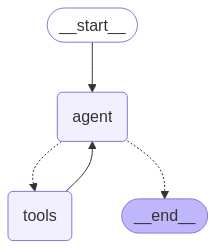

In [ ]:
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI

chatgpt = ChatOpenAI(model="gpt-4o", temperature=0)

text2sql_agent = create_react_agent(model=chatgpt,
                                    tools=sql_tools,
                                    state_modifier=SYS_PROMPT)
text2sql_agent

## Run and Test Text2SQL Agent

In [ ]:
from IPython.display import display, Markdown

for s in text2sql_agent.stream(
    {"messages": [HumanMessage(content="What is the total number of customers?")]}
):
    display(Markdown(str(s)))
    print("----")

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_o3JcFvFNWYMLqWP3rBGANelJ', 'function': {'arguments': '{}', 'name': 'sql_db_list_tables'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 649, 'total_tokens': 662, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb9dce56a8', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-276024fc-a6a2-4b79-acc8-8016693e527b-0', tool_calls=[{'name': 'sql_db_list_tables', 'args': {}, 'id': 'call_o3JcFvFNWYMLqWP3rBGANelJ', 'type': 'tool_call'}], usage_metadata={'input_tokens': 649, 'output_tokens': 13, 'total_tokens': 662, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}

----


{'tools': {'messages': [ToolMessage(content='Branch, Comic, Customer, Employee, Inventory, Publisher, Sale, SaleTransactions', name='sql_db_list_tables', id='580f28de-5087-4d06-b040-40256dc77489', tool_call_id='call_o3JcFvFNWYMLqWP3rBGANelJ')]}}

----


{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_ZHPIlqjvd0MRjzaE38jmWbnI', 'function': {'arguments': '{"table_names":"Customer"}', 'name': 'sql_db_schema'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 687, 'total_tokens': 704, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb9dce56a8', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-a6066bed-e341-40da-ba01-3c1dc1f91a56-0', tool_calls=[{'name': 'sql_db_schema', 'args': {'table_names': 'Customer'}, 'id': 'call_ZHPIlqjvd0MRjzaE38jmWbnI', 'type': 'tool_call'}], usage_metadata={'input_tokens': 687, 'output_tokens': 17, 'total_tokens': 704, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}

...

----


{'tools': {'messages': [ToolMessage(content='[(20,)]', name='sql_db_query', id='4ad8dcd7-941e-485c-ba9f-8aecc0b060ac', tool_call_id='call_UZixHSgDAjxe5vbhGyXABJnb')]}}

----


{'agent': {'messages': [AIMessage(content='The total number of customers is 20.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 1049, 'total_tokens': 1060, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1024}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb9dce56a8', 'finish_reason': 'stop', 'logprobs': None}, id='run-87bb3b0a-68ac-47bd-ac68-8370fff71018-0', usage_metadata={'input_tokens': 1049, 'output_tokens': 11, 'total_tokens': 1060, 'input_token_details': {'audio': 0, 'cache_read': 1024}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}

----


In [ ]:
for event in text2sql_agent.stream(
    {"messages": [HumanMessage(content="What are the Top 10 most popular comics?")]},
    stream_mode='values' #returns full agent state with all messages including updates
):
    event["messages"][-1].pretty_print()

print('\n\nFinal Response:\n')
display(Markdown(event["messages"][-1].content))

================================ Human Message =================================

What are the Top 10 most popular comics?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_qfKbi9gNYLsnCNeecR37SZif)
 Call ID: call_qfKbi9gNYLsnCNeecR37SZif
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Branch, Comic, Customer, Employee, Inventory, Publisher, Sale, SaleTransactions
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_C4KCpoSU4AT3y4MeEzNWVkN3)
 Call ID: call_C4KCpoSU4AT3y4MeEzNWVkN3
  Args:
    table_names: Comic, Sale
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Comic" (
	"ComicId" INTEGER NOT NULL, 
	"Title" NVARCHAR(100) NOT NULL, 
	"PublisherId" INTEGER NOT NULL, 
	"Genre" NVARCHAR(50), 
	"Price" NUMERIC(10, 2) NOT NU

Here are the Top 10 most popular comics based on sales:

1. Wolverine: Old Man Logan - 3 copies sold
2. Superman: Red Son - 2 copies sold
3. Ms. Marvel Volume 1 - 2 copies sold
4. Iron Man: Extremis - 2 copies sold
5. Locke & Key Volume 1 - 2 copies sold
6. V for Vendetta - 2 copies sold
7. The Boys Volume 1 - 2 copies sold
8. Lumberjanes Volume 1 - 2 copies sold
9. Punisher: Welcome Back, Frank - 2 copies sold
10. Invincible Volume 1 - 2 copies sold

In [ ]:
def call_text2sql_agent(query, verbose=False):

    for event in text2sql_agent.stream(
        {"messages": [HumanMessage(content=query)]},
        stream_mode='values' #returns full agent state with all messages including updates
    ):
        if verbose:
            event["messages"][-1].pretty_print()

    print('\n\nFinal Response:\n')
    display(Markdown(event["messages"][-1].content))


In [ ]:
call_text2sql_agent(query="What are the Top 10 most popular comics?",
                    verbose=True)

================================ Human Message =================================

What are the Top 10 most popular comics?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_SY2qnOwR08Tjtd1XHmUsChjs)
 Call ID: call_SY2qnOwR08Tjtd1XHmUsChjs
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Branch, Comic, Customer, Employee, Inventory, Publisher, Sale, SaleTransactions
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_0U6FjhKeAFEZkJNdGS2beRG1)
 Call ID: call_0U6FjhKeAFEZkJNdGS2beRG1
  Args:
    table_names: Comic, Sale
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Comic" (
	"ComicId" INTEGER NOT NULL, 
	"Title" NVARCHAR(100) NOT NULL, 
	"PublisherId" INTEGER NOT NULL, 
	"Genre" NVARCHAR(50), 
	"Price" NUMERIC(10, 2) NOT NU

Here are the Top 10 most popular comics based on sales:

1. Wolverine: Old Man Logan - 3 copies sold
2. Superman: Red Son - 2 copies sold
3. Ms. Marvel Volume 1 - 2 copies sold
4. Iron Man: Extremis - 2 copies sold
5. Locke & Key Volume 1 - 2 copies sold
6. V for Vendetta - 2 copies sold
7. The Boys Volume 1 - 2 copies sold
8. Lumberjanes Volume 1 - 2 copies sold
9. Punisher: Welcome Back, Frank - 2 copies sold
10. Invincible Volume 1 - 2 copies sold

In [ ]:
call_text2sql_agent(query="What are the top 5 customers with most comics purchased?",
                    verbose=False)



Final Response:



The top 5 customers with the most comics purchased are:

1. Tony Stark - 8 comics
2. Sarah Connor - 7 comics
3. Natasha Romanoff - 6 comics
4. Clark Kent - 6 comics
5. Diana Prince - 6 comics

In [ ]:
call_text2sql_agent(query="Which are the top 5 customers with most money spent",
                    verbose=False)



Final Response:



The top 5 customers with the most money spent are:

1. Tony Stark - \$164.94
2. Bruce Wayne - \$139.94
3. Sarah Connor - \$124.96
4. Clark Kent - \$114.96
5. Natasha Romanoff - \$111.96

In [ ]:
call_text2sql_agent(query="Which are the top 3 salesman with highest revenue",
                    verbose=False)



Final Response:



The top 3 salesmen with the highest revenue are:

1. John Doe with a total revenue of \$255.89
2. Alice Brown with a total revenue of \$234.94
3. Jane Smith with a total revenue of \$234.88

In [ ]:
query = "What are the Top 10 most popular comics?"
results = text2sql_agent.invoke(
        {"messages": [HumanMessage(content=query)]}
        )

In [ ]:
display(Markdown(results["messages"][-1].content))

Here are the Top 10 most popular comics based on the number of copies sold:

1. Wolverine: Old Man Logan - 3 copies
2. Superman: Red Son - 2 copies
3. Ms. Marvel Volume 1 - 2 copies
4. Iron Man: Extremis - 2 copies
5. Locke & Key Volume 1 - 2 copies
6. V for Vendetta - 2 copies
7. The Boys Volume 1 - 2 copies
8. Lumberjanes Volume 1 - 2 copies
9. Punisher: Welcome Back, Frank - 2 copies
10. Invincible Volume 1 - 2 copies

<h2>Text2SQL with Supervisor Agent</h2>

Coding Tool

In [ ]:
from langchain_experimental.utilities import PythonREPL
from langchain_core.tools import tool
from typing import Annotated

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute code, generate charts."],
):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nCODE OUTPUT:\n {result}"
    return result_str

<h3>Create Agent Supervisor</h3>

It will use LLM with structured output routing to choose the next worker node (sub-agent) OR finish processing.

In [ ]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END
from langgraph.types import Command
from langgraph.graph.message import add_messages
#from langchain.chat_models import ChatOpenAI
from langchain_openai import ChatOpenAI


# Our team supervisor is an LLM node. It just picks the next agent to process
# and decides when the work is completed
members = ["researcher", "coder"]

SUPERVISOR_AGENT_PROMPT = f"""You are a supervisor tasked with managing a conversation between the following workers:
                              {members}.

                              Given the following user request, respond with the worker to act next.
                              Each worker will perform a task and respond with their results and status.
                              Analyze the results carefully and decide which worker to call next accordingly.
                              Remember researcher agent can search for information and coder agent can code.
                              When finished, respond with FINISH."""


class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""
    next: Literal["researcher", "coder", "FINISH"]

class State(TypedDict):
    messages: Annotated[list, add_messages]
    next: str

#llm = ChatOpenAI(model="gpt-4o", temperature=0)
chatgpt = ChatOpenAI(model="gpt-4o", temperature=0)

def supervisor_node(state: State) -> Command[Literal["researcher", "coder", "__end__"]]:
    messages = [{"role": "system", "content": SUPERVISOR_AGENT_PROMPT},] + state["messages"]
    response = chatgpt.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    if goto == "FINISH":
        goto = END

    return Command(goto=goto, update={"next": goto})

<h3>Construct Graph with Supervisor Agent and Worker Sub-Agents</h3>


We're ready to start building the graph. Below, we define the sub-agents and connect them as nodes to the supervisor agent node

We use the LangGraph built-in create_react_agent(...) function to build the two tool-based sub-agents easily

In [ ]:
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import trim_messages

# Create Financial Researcher Sub-Agent
chatgpt = ChatOpenAI(model="gpt-4o", temperature=0)

text2sql_agent = create_react_agent(model=chatgpt,
                                    tools=sql_tools,
                                    state_modifier=SYS_PROMPT)

# create node function for financial researcher sub-agent
def research_node(state: State) -> Command[Literal["supervisor"]]:
    result = text2sql_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )


# Create Coder Sub-Agent
code_agent = create_react_agent(chatgpt, tools=[python_repl_tool], state_modifier="""You are a coder who can write and run python code and also visualize charts and graphs.
                                                                                 Only extract the most relevant data related to the question before running code or creating graphs.
                                                                                 Once your task is done report back to the supervisor.""")

# create node function for coder sub-agent
def code_node(state: State) -> Command[Literal["supervisor"]]:
    result = code_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )

# build the agent graph
builder = StateGraph(State)
builder.add_edge(START, "supervisor")
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", research_node)
builder.add_node("coder", code_node)
graph = builder.compile()

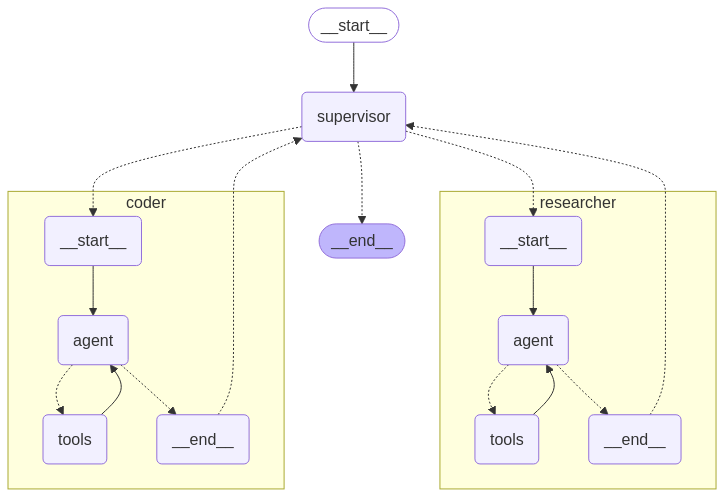

In [ ]:
from IPython.display import display, Image, Markdown

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
def call_multi_agent_system(agent, prompt):
    events = agent.stream(
        {"messages": [("user", prompt)]},
        {"recursion_limit": 3},
        stream_mode="values",

    )

    for event in events:
        event["messages"][-1].pretty_print()

    display(Markdown(event["messages"][-1].content))


def call_multi_agent_system2(agent, prompt):
    for event in agent.stream(
        {"messages": [("user", prompt)]},
        {"recursion_limit": 30},
        stream_mode="values",

    ):
      event["messages"][-1].pretty_print()


    display(Markdown(event["messages"][-1].content))



================================ Human Message =================================

Get the top 3 salesman with highest revenue
           and display it as a bar chart
================================ Human Message =================================

Get the top 3 salesman with highest revenue
           and display it as a bar chart
================================ Human Message =================================
Name: researcher

Here are the top 3 salesmen with the highest revenue:

1. **John Doe**: \$255.89
2. **Alice Brown**: \$234.94
3. **Jane Smith**: \$234.88

You can visualize this data as a bar chart with the salesmen on the x-axis and their total revenue on the y-axis.
================================ Human Message =================================
Name: researcher

Here are the top 3 salesmen with the highest revenue:

1. **John Doe**: \$255.89
2. **Alice Brown**: \$234.94
3. **Jane Smith**: \$234.88

You can visualize this data as a bar chart with the salesmen on the x-axis a

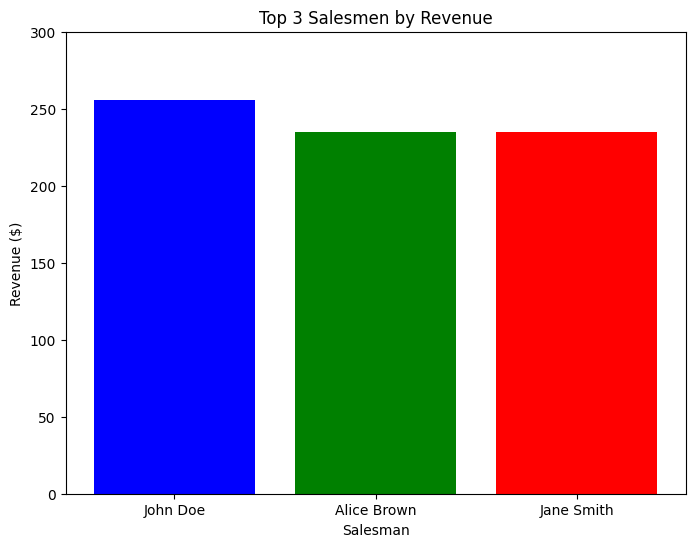

================================ Human Message =================================
Name: coder

The bar chart displaying the top 3 salesmen by revenue has been successfully created. If you need any further assistance, feel free to ask!
================================ Human Message =================================
Name: coder

The bar chart displaying the top 3 salesmen by revenue has been successfully created. If you need any further assistance, feel free to ask!


The bar chart displaying the top 3 salesmen by revenue has been successfully created. If you need any further assistance, feel free to ask!

In [ ]:
query = """Get the top 3 salesman with highest revenue
           and display it as a bar chart"""
call_multi_agent_system2(graph, query)

================================ Human Message =================================

 
Display the top 5 customers with most comics purchased as a graph.
        
================================ Human Message =================================

 
Display the top 5 customers with most comics purchased as a graph.
        
================================ Human Message =================================
Name: coder

To display the top 5 customers with the most comics purchased as a graph, I need to know the data source or have access to the relevant data. Could you please provide the data or specify where I can access it?
================================ Human Message =================================
Name: coder

To display the top 5 customers with the most comics purchased as a graph, I need to know the data source or have access to the relevant data. Could you please provide the data or specify where I can access it?
================================ Human Message =========================

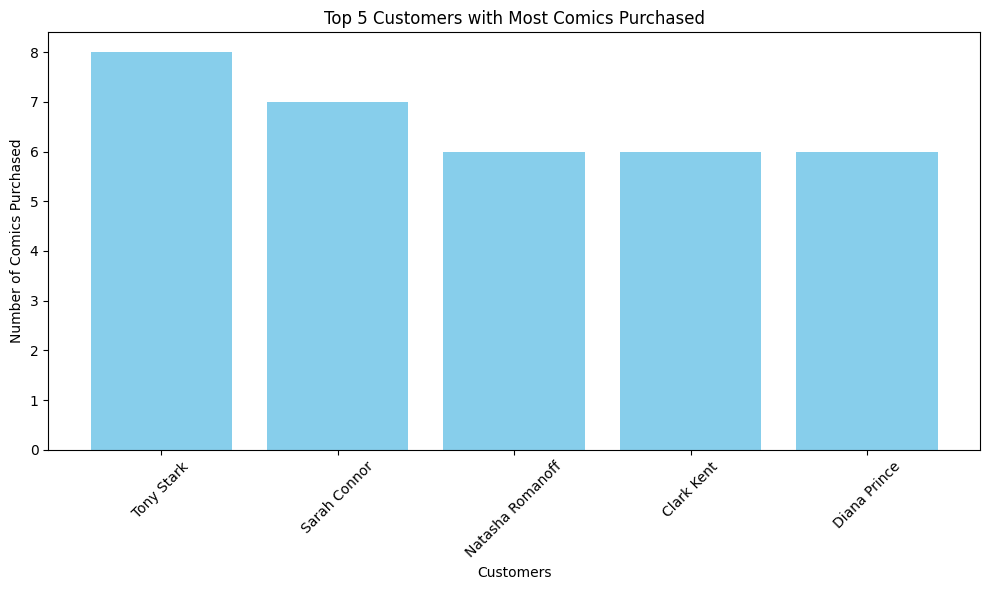

================================ Human Message =================================
Name: coder

The bar chart displaying the top 5 customers with the most comics purchased has been successfully created. If you need any further assistance, please let me know!
================================ Human Message =================================
Name: coder

The bar chart displaying the top 5 customers with the most comics purchased has been successfully created. If you need any further assistance, please let me know!


The bar chart displaying the top 5 customers with the most comics purchased has been successfully created. If you need any further assistance, please let me know!

In [ ]:
query = """
Display the top 5 customers with most comics purchased as a graph.
        """
call_multi_agent_system2(graph, query)

<h2>3. Text2SQL with LangGraph including Reasoning Step and SQL</h2>

In [ ]:
import os
from typing import Dict, Any
import sqlite3
import re

from typing_extensions import TypedDict
from typing import Annotated, Optional
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_community.utilities import SQLDatabase
from sqlalchemy import create_engine
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
def create_and_populate_db():
    # Connect to SQLite database (or create it if it doesn't exist)
    conn = sqlite3.connect("artist_album.db")
    cursor = conn.cursor()

    # Create tables
    cursor.executescript('''
    CREATE TABLE IF NOT EXISTS Artist (
        ArtistId INTEGER PRIMARY KEY AUTOINCREMENT,
        Name TEXT NOT NULL
    );

    CREATE TABLE IF NOT EXISTS Album (
        AlbumId INTEGER PRIMARY KEY AUTOINCREMENT,
        Title TEXT NOT NULL,
        ArtistId INTEGER NOT NULL,
        FOREIGN KEY (ArtistId) REFERENCES Artist(ArtistId) ON DELETE CASCADE
    );

    CREATE TABLE IF NOT EXISTS Invoice (
        InvoiceId INTEGER PRIMARY KEY AUTOINCREMENT,
        CustomerId INTEGER NOT NULL,
        Total REAL NOT NULL
    );

    CREATE TABLE IF NOT EXISTS InvoiceLine (
        InvoiceLineId INTEGER PRIMARY KEY AUTOINCREMENT,
        InvoiceId INTEGER NOT NULL,
        TrackId INTEGER NOT NULL,
        UnitPrice REAL NOT NULL,
        Quantity INTEGER NOT NULL,
        FOREIGN KEY (InvoiceId) REFERENCES Invoice(InvoiceId) ON DELETE CASCADE
    );
    ''')

    # Insert data into Artist table
    cursor.executemany("""
    INSERT INTO Artist (Name) VALUES (?)
    """, [
        ('The Beatles',),
        ('Pink Floyd',),
        ('Led Zeppelin',),
        ('Queen',)
    ])

    # Insert data into Album table
    cursor.executemany("""
    INSERT INTO Album (Title, ArtistId) VALUES (?, ?)
    """, [
        ('Abbey Road', 1),
        ('The Dark Side of the Moon', 2),
        ('Led Zeppelin IV', 3),
        ('A Night at the Opera', 4)
    ])

    # Insert data into Invoice table
    cursor.executemany("""
    INSERT INTO Invoice (CustomerId, Total) VALUES (?, ?)
    """, [
        (1, 29.99),
        (2, 19.99),
        (3, 39.99)
    ])

    # Insert data into InvoiceLine table
    cursor.executemany("""
    INSERT INTO InvoiceLine (InvoiceId, TrackId, UnitPrice, Quantity) VALUES (?, ?, ?, ?)
    """, [
        (1, 101, 9.99, 1),
        (1, 102, 4.99, 2),
        (2, 103, 9.99, 1),
        (3, 104, 19.99, 2)
    ])

    # Commit changes and close connection
    conn.commit()
    conn.close()
    print("Database 'artist_album.db' created and populated successfully.")

if __name__ == "__main__":
    create_and_populate_db()

In [ ]:
#db = SQLDatabase.from_uri("sqlite:///ComicStore.db")
db = SQLDatabase.from_uri("sqlite:///artist_album.db")

In [ ]:
# Create the toolkit
toolkit = SQLDatabaseToolkit(db=db, llm=ChatOpenAI(model="gpt-4o-mini"))
sql_db_toolkit_tools = toolkit.get_tools()

In [ ]:
from langchain_experimental.utilities import PythonREPL
from langchain_core.tools import tool
from typing import Annotated

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute code, generate charts."],
):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nCODE OUTPUT:\n {result}"
    return result_str

**Prompt Template**

Design an elaborate prompt template that guides the reasoning. The sections include:

reasoning
analysis
query
error check
final check

In [ ]:
query_gen_system = """
I am an SQL expert who helps analyze database queries. I have access to tools for interacting with the database. When given a question, I'll think through it carefully and explain my reasoning in natural language.

Then I'll walk through my analysis process:

1. First, I'll understand what tables and data I need
2. Then, I'll verify the schema and relationships
3. Finally, I'll construct an appropriate SQL query

For each query, I'll think about:
- What tables are involved and how they connect
- Any special conditions or filters needed
- How to handle potential edge cases
- The most efficient way to get the results

<reasoning>
I will **always** include this section before writing a query. Here, I will:
- Explain what information I need and why
- Describe my expected outcome
- Identify potential challenges
- Justify my query structure

If this section is missing, I will rewrite my response to include it.
</reasoning>

<analysis>
Here I break down the key components needed for the query:
- Required tables and joins
- Important columns and calculations
- Any specific filters or conditions
- Proper ordering and grouping
</analysis>

<query>
The final SQL query
</query>

<error_check>
If there's an error, I'll explain:
- What went wrong
- Why it happened
- How to fix it
</error_check>

<final_check>
Before finalizing, I will verify:
- Did I include a clear reasoning section?
- Did I explain my approach before querying?
- Did I provide an analysis of the query structure?
- If any of these are missing, I will revise my response.
</final_check>

Important rules:
1. Only use SELECT statements, no modifications
2. Verify all schema assumptions
3. Use proper SQLite syntax
4. Limit results to 10 unless specified
5. Double-check all joins and conditions
6. Always include tool_analysis and tool_reasoning for each tool call
"""

query_gen_prompt = ChatPromptTemplate.from_messages([
    ("system", query_gen_system),
    MessagesPlaceholder(variable_name="messages"),
])

query_gen_model = query_gen_prompt | ChatOpenAI(
    model="gpt-4o-mini", temperature=0).bind_tools(tools=sql_db_toolkit_tools)

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

def query_gen_node(state: State):
    return {"messages": [query_gen_model.invoke(state["messages"])]}

checkpointer = MemorySaver()

graph_builder.add_node("query_gen", query_gen_node)
query_gen_tools_node = ToolNode(tools=sql_db_toolkit_tools)
plot_gen_tools_node = ToolNode(tools=[python_repl_tool])
graph_builder.add_node("query_gen_tools", query_gen_tools_node)
#graph_builder.add_node("plot_gen_tools", plot_gen_tools_node)

graph_builder.add_conditional_edges(
    "query_gen",
    tools_condition,
    {"tools": "query_gen_tools", END: END},
)

graph_builder.add_edge("query_gen_tools", "query_gen")
#graph_builder.add_edge("query_gen","plot_gen_tools")
#graph_builder.add_edge("plot_gen_tools","query_gen",)
graph_builder.set_entry_point("query_gen")
graph = graph_builder.compile(checkpointer=checkpointer)

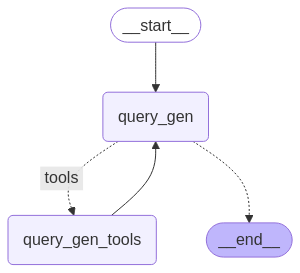

In [ ]:
graph

In [ ]:
def format_section(title: str, content: str) -> str:
    if not content:
        return ""
    return f"\n{content}\n"

def extract_section(text: str, section: str) -> str:
    pattern = f"<{section}>(.*?)</{section}>"
    match = re.search(pattern, text, re.DOTALL)
    return match.group(1).strip() if match else ""

def process_event(event: Dict[str, Any]) -> Optional[str]:
    if 'query_gen' in event:
        messages = event['query_gen']['messages']
        for message in messages:
            content = message.content if hasattr(message, 'content') else ""

            reasoning = extract_section(content, "reasoning")
            if reasoning:
                print(format_section("", reasoning))

            analysis = extract_section(content, "analysis")
            if analysis:
                print(format_section("", analysis))

            error_check = extract_section(content, "error_check")
            if error_check:
                print(format_section("", error_check))

            final_check = extract_section(content, "final_check")
            if final_check:
                print(format_section("", final_check))

            if hasattr(message, 'tool_calls'):
                for tool_call in message.tool_calls:
                    tool_name = tool_call['name']
                    if tool_name == 'sql_db_query':
                        return tool_call['args']['query']

            query = extract_section(content, "query")
            if query:
                sql_match = re.search(
                    r'```sql\n(.*?)\n```', query, re.DOTALL)
                if sql_match:
                    return format_section("", query)

    return None

In [ ]:
def run_query(query_text: str):
    print(f"\nAnalyzing your question: {query_text}")
    final_sql = None

    for event in graph.stream({"messages": [("user", query_text)]},
                              config={"configurable": {"thread_id": 12}}):
        sql = process_event(event)
        if sql:
            final_sql = sql

    if final_sql:
        print(
            "\nBased on my analysis, here's the SQL query that will answer your question:")
        print(f"\n{final_sql}")
        return final_sql

In [ ]:
def interactive_sql():
    print("\nWelcome to the SQL Assistant! Type 'exit' to quit.")

    while True:
        try:
            query = input("\nWhat would you like to know? ")
            if query.lower() in ['exit', 'quit']:
                print("\nThank you for using SQL Assistant!")
                break

            run_query(query)

        except KeyboardInterrupt:
            print("\nThank you for using SQL Assistant!")
            break
        except Exception as e:
            print(f"\nAn error occurred: {str(e)}")
            print("Please try again with a different query.")


In [ ]:
#if __name__ == "__main__":
#    interactive_sql()

In [ ]:
query_text = "What are the top 3 best-selling tracks by revenue?"
for event in graph.stream({"messages": [("user", query_text)]},
                              config={"configurable": {"thread_id": 200}}):
        #sql = process_event(event)
        process_event(event)


To determine the top 3 best-selling tracks by revenue, I need to analyze the relevant tables that contain information about tracks and their sales. Typically, this would involve a "tracks" table that includes track details and a "sales" or "orders" table that records sales transactions.

My expected outcome is to retrieve the names of the top 3 tracks along with their total revenue generated from sales. The challenge here is to ensure that I correctly join the tables and aggregate the sales data to calculate the total revenue for each track.

I will need to:
1. Identify the tables involved (likely "tracks" and "sales").
2. Verify the schema to confirm the necessary columns for joining and calculating revenue.
3. Construct a SQL query that sums the revenue for each track, orders the results by revenue in descending order, and limits the output to the top 3 tracks.

This will ensure that I get the correct results efficiently.


1. Required tables: "tracks" and "sales".
2. Important colu

In [ ]:
message = graph.invoke({"messages": [("user", query_text)]},
                              config={"configurable": {"thread_id": 150}})

reasoning = None
analysis = None
query = None
final_check = None
for msg in message['messages']:
    # Ensure 'content' is a string before extraction
    if isinstance(msg.content, str):
        extracted_reasoning = extract_section(msg.content, "reasoning")
        if extracted_reasoning:
            reasoning = extracted_reasoning
            #break  # Stop if reasoning is found
        extracted_analysis = extract_section(msg.content, "analysis")
        if extracted_analysis:
            analysis = extracted_analysis
            #break  # Stop if reasoning is found
        extracted_query = extract_section(msg.content, "query")
        if extracted_query:
            query = extracted_query
            #break  # Stop if reasoning is found

        extracted_final_check = extract_section(msg.content, "final_check")
        if extracted_final_check:
            final_check = extracted_final_check
            #break  # Stop if reasoning is found

In [ ]:
#message['messages']
#reasoning = extract_section(message['messages'], "reasoning")


#for message in message['messages']:
#    content = message.content if hasattr(message, 'content') else ""

#    reasoning = extract_section(content, "reasoning")

In [ ]:
#f"\n{final_check}\n"
print(format_section("", final_check))


- I included a clear reasoning section explaining the approach to find the top 3 best-selling tracks by revenue.
- I provided an analysis of the query structure, detailing the necessary tables and calculations.
- I constructed and executed the SQL query successfully.

The results indicate the top 3 best-selling tracks by revenue:
1. **TrackId 104**: Total Revenue of $39.98
2. **TrackId 103**: Total Revenue of $9.99
3. **TrackId 101**: Total Revenue of $9.99

However, please note that without the "Track" table, I cannot provide the names of these tracks. If you need further details or have any other questions, feel free to ask!



In [ ]:
#extracted_query = extract_section(message["messages"][7].content, "query")
#analysis
sql_match = re.search(r'```sql\n(.*?)\n```', query, re.DOTALL)
#if sql_match:
#format_section("", query)
f"\n{query}\n"

'\n```sql\nSELECT TrackId, SUM(UnitPrice * Quantity) AS TotalRevenue\nFROM InvoiceLine\nGROUP BY TrackId\nORDER BY TotalRevenue DESC\nLIMIT 3;\n```\n'

In [ ]:
#!pip install gradio

In [ ]:
import gradio as gr
from uuid import uuid4

history = {}
session_id = str(uuid4())

def chat(query_text):

    # Initialize the chat history for the current session
    if session_id not in history:
        history[session_id] = []

    chat_history = history[session_id]

    # Invoke the app with the current query and chat history
    #result = app.invoke({"query": query, "chat_history": chat_history})

    result = graph.invoke({"messages": [("user", query_text)]},
                              config={"configurable": {"thread_id": 150}})

    # Separate the response from the retrieved documents
    reasoning = None
    analysis = None
    query = None
    final_check = None
    for msg in result['messages']:
        # Ensure 'content' is a string before extraction
        if isinstance(msg.content, str):
            extracted_reasoning = extract_section(msg.content, "reasoning")
            if extracted_reasoning:
                reasoning = extracted_reasoning
                #break  # Stop if reasoning is found
            extracted_analysis = extract_section(msg.content, "analysis")
            if extracted_analysis:
                analysis = extracted_analysis
                #break  # Stop if reasoning is found
            extracted_query = extract_section(msg.content, "query")
            if extracted_query:
                query = extracted_query
                #break  # Stop if reasoning is found

            extracted_final_check = extract_section(msg.content, "final_check")
            if extracted_final_check:
                final_check = extracted_final_check
    # Add the current exchange to the chat history
    #chat_history.extend([HumanMessage(content=query), AIMessage(content=response)])



    return reasoning, query

In [ ]:
demo = gr.Interface(
    fn=chat,
    inputs=gr.Textbox(label="Question"),
    outputs=[gr.Textbox(label="Response"), gr.Textbox(label="Query")],
    title="Text SQL Chatbot",
    description="Ask a health-related query and the chatbot will generate a response using Retrieval Augmented Generation.",
)

if __name__ == "__main__":
    demo.launch(share=True, inline=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://481f8612dbe540f678.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<h1>4. Text2QSL_with_few_shots</h1>

In [1]:
!pip install langchain==0.3.14
!pip install langchain-openai==0.3.0
!pip install langchain-community==0.3.14
!pip install langgraph==0.2.66
!pip install langchain-experimental==0.3.4
!pip install streamlit
!apt-get install sqlite3 -y
!pip install faiss-cpu
!pip install aiohttp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.9/326.9 kB 17.5 MB/s eta 0:00:00
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.3.13
    Uninstalling langsmith-0.3.13:
      Successfully uninstalled langsmith-0.3.13
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.20
    Uninstalling langchain-0.3.20:
      Successfully uninstalled langchain-0.3.20
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import re

import streamlit as st
from langchain.agents import create_sql_agent
from langchain_community.vectorstores import FAISS
from langchain_core.example_selectors import SemanticSimilarityExampleSelector
from langchain_core.messages import AIMessage
from langchain_core.prompts import (
    SystemMessagePromptTemplate,
    PromptTemplate,
    FewShotPromptTemplate,
)
from langchain_core.prompts.chat import (
    ChatPromptTemplate,
    HumanMessagePromptTemplate,
    MessagesPlaceholder,
)
from langchain_experimental.utilities import PythonREPL
from langchain.memory import ConversationBufferMemory
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain.sql_database import SQLDatabase
from langchain.tools import Tool

In [3]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

Enter Open AI API Key: ··········


In [4]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY

In [5]:
db = SQLDatabase.from_uri("sqlite:///customer_profiles.db")

In [6]:
sql_examples = [
    {
        "input": "Count of Customers by Source System",
        "query": f"""
            SELECT
                source_system,
                COUNT(*) AS customer_count
            FROM
                customer
            GROUP BY
                source_system
            ORDER BY
                customer_count DESC;
        """,
    },
    {
        "input": "Average Age of Customers by Gender",
        "query": """
            SELECT Gender, AVG(CAST(strftime('%Y', 'now') - strftime('%Y', DateOfBirth) AS INTEGER)) AS AverageAge
            FROM Customer
            WHERE DateOfBirth IS NOT NULL
            GROUP BY Gender;
        """,

    },
    {
        "input": "Distribution of Customers by Age Groups",
        "query": f"""
            SELECT
                CASE
                    WHEN CAST(strftime('%Y', 'now') - strftime('%Y', DateOfBirth) AS INTEGER) < 20 THEN 'Under 20'
                    WHEN CAST(strftime('%Y', 'now') - strftime('%Y', DateOfBirth) AS INTEGER) BETWEEN 20 AND 29 THEN '20-29'
                    WHEN CAST(strftime('%Y', 'now') - strftime('%Y', DateOfBirth) AS INTEGER) BETWEEN 30 AND 39 THEN '30-39'
                    WHEN CAST(strftime('%Y', 'now') - strftime('%Y', DateOfBirth) AS INTEGER) BETWEEN 40 AND 49 THEN '40-49'
                    WHEN CAST(strftime('%Y', 'now') - strftime('%Y', DateOfBirth) AS INTEGER) BETWEEN 50 AND 59 THEN '50-59'
                    ELSE '60 and above'
                END AS AgeGroup,
                COUNT(*) AS CustomerCount
            FROM Customer
            WHERE DateOfBirth IS NOT NULL
            GROUP BY AgeGroup
            ORDER BY CustomerCount DESC;
        """,
    }]

PREFIX = """
You are a SQL expert. You have access to a SQL lite database.
Identify which tables can be used to answer the user's question and write and execute a SQL query accordingly.
Given an input question, create a syntactically correct SQL query to run against the dataset customer_profiles, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most {top_k} results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table; only ask for the relevant columns given the question.
You have access to tools for interacting with the database.
Only use the information returned by these tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

If the question does not seem related to the database, just return "I don't know" as the answer.

If the user asks for a visualization of the results, use the python_agent tool to create and display the visualization.


"""

SUFFIX = """Begin!

{chat_history}

Question: {input}
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
{agent_scratchpad}"""




In [7]:
python_repl = PythonREPL()


def sql_agent_tools():
    tools = [
        Tool(
            name="python_repl",
            description=f"A Python shell. Use this to execute python commands. \
              Input should be a valid python command. \
              If you want to see the output of a value, \
              you should print it out with `print(...)`.",
            func=python_repl.run,
        ),
    ]
    return tools


example_selector = SemanticSimilarityExampleSelector.from_examples(
    sql_examples,
    OpenAIEmbeddings(),
    FAISS,
    k=2,
    input_keys=["input"],
)

few_shot_prompt = FewShotPromptTemplate(
    example_selector=example_selector,
    example_prompt=PromptTemplate.from_template(
        "User input: {input}\nSQL query: {query}"
    ),
    prefix=PREFIX,
    suffix="",
    input_variables=["input", "top_k"],
    example_separator="\n\n",
)

messages = [
    SystemMessagePromptTemplate(prompt=few_shot_prompt),
    MessagesPlaceholder(variable_name="chat_history"),
    HumanMessagePromptTemplate.from_template("{input}"),
    AIMessage(content=SUFFIX),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
]
prompt = ChatPromptTemplate.from_messages(messages)
extra_tools = sql_agent_tools()

memory = ConversationBufferMemory(
    memory_key="chat_history", return_messages=True, input_key="input"
)

model = ChatOpenAI(model="gpt-4o", temperature=0)

agent_executor = create_sql_agent(
    llm=model,
    db=db,
    verbose=True,
    top_k=10,
    prompt=prompt,
    extra_tools=extra_tools,
    input_variables=["input", "agent_scratchpad", "chat_history"],
    agent_type="openai-tools",
    agent_executor_kwargs={"handle_parsing_errors": True, "memory": memory},
)

<ipython-input-7-5d43c0b491d8>:47: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(




> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`


Address, Contact, Customer, CustomerAddress
Invoking: `sql_db_schema` with `{'table_names': 'Customer'}`



CREATE TABLE "Customer" (
	"CustomerID" INTEGER, 
	"FirstName" TEXT NOT NULL, 
	"LastName" TEXT NOT NULL, 
	"DateOfBirth" TEXT, 
	"Email" TEXT, 
	"Source_System" TEXT, 
	"Gender" TEXT, 
	PRIMARY KEY ("CustomerID"), 
	UNIQUE ("Email")
)

/*
3 rows from Customer table:
CustomerID	FirstName	LastName	DateOfBirth	Email	Source_System	Gender
1	Customer1	Last1	1972-02-16	customer1@example.com	Mobile App	Male
2	Customer2	Last2	1958-04-23	customer2@example.com	Social Media	Male
3	Customer3	Last3	1990-02-21	customer3@example.com	CRM	Other
*/
Invoking: `sql_db_query_checker` with `{'query': "SELECT \n    CASE \n        WHEN CAST(strftime('%Y', 'now') - strftime('%Y', DateOfBirth) AS INTEGER) < 20 THEN 'Under 20'\n        WHEN CAST(strftime('%Y', 'now') - strftime('%Y', DateOfBirth) AS INTEGER) BETWEEN 20


Invoking: `python_repl` with `import matplotlib.pyplot as plt
import pandas as pd

# Data from the query
age_gender_data = [
    ('20-29', 'Female', 2),
    ('20-29', 'Other', 1),
    ('30-39', 'Female', 2),
    ('30-39', 'Other', 2),
    ('40-49', 'Female', 4),
    ('50-59', 'Male', 1),
    ('60 and above', 'Female', 3),
    ('60 and above', 'Male', 4),
    ('60 and above', 'Other', 1)
]

# Create a DataFrame
df = pd.DataFrame(age_gender_data, columns=['AgeGroup', 'Gender', 'CustomerCount'])

# Pivot the DataFrame for plotting
pivot_df = df.pivot(index='AgeGroup', columns='Gender', values='CustomerCount').fillna(0)

# Plotting
pivot_df.plot(kind='bar', stacked=True)
plt.title('Customer Distribution by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()`




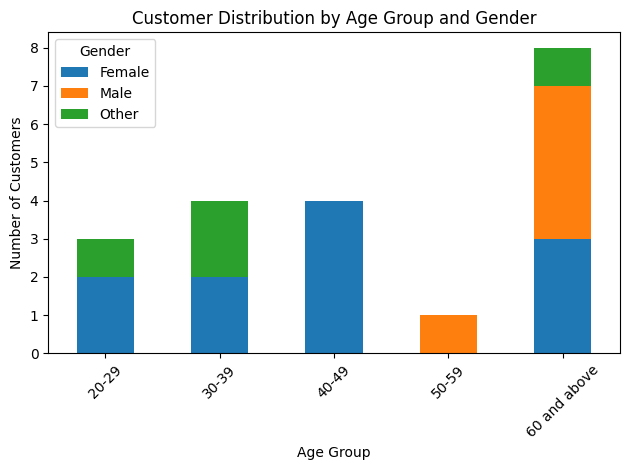

Here is the visualization of the customer distribution by age group and gender:

![Customer Distribution by Age Group and Gender](sandbox:/mnt/data/plot.png)

The bar chart shows the number of customers in each age group, broken down by gender.

> Finished chain.


In [9]:
user_input="get the age groups versus gender and visualize it"
response = agent_executor.run(input=user_input)

In [10]:
!npm install localtunnel
!streamlit run data_analytics.py --server.address=localhost &>/content/logs.txt &
import urllib
print("Password local tunnel is", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8'))

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼Password local tunnel is 34.23.70.28



In [11]:
!npx localtunnel --port 8501

⠙your url is: https://eighty-ghosts-tickle.loca.lt
^C
